In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn openpyxl faker

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.0 MB 2.0 MB/s eta 0:00:01
   -------------------- ------------------- 1.0/2.0 MB 1.9 MB/s eta 0:00:01
   ------------------------------- -------- 1.6/2.0 MB 1.9 MB/s eta 0:00:01
   ------------------------------------ --- 1.8/2.0 MB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 1.7 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
from faker import Faker
import random
from datetime import datetime, timedelta

fake = Faker()
np.random.seed(42)
random.seed(42)

departments = ['Engineering', 'Finance', 'Product', 'Sales', 'HR']
job_levels = ['L1 - Analyst', 'L2 - Senior Analyst', 'L3 - Manager', 'L4 - Senior Manager', 'L5 - Director']

skills_by_dept = {
    'Engineering': ['Python', 'Cloud Architecture', 'Data Engineering', 'Cybersecurity', 'ML/AI', 'DevOps'],
    'Finance':     ['Financial Modelling', 'Risk Analysis', 'FP&A', 'Regulatory Compliance', 'Audit', 'Treasury'],
    'Product':     ['Product Strategy', 'User Research', 'Roadmapping', 'Data Analysis', 'Agile', 'Stakeholder Management'],
    'Sales':       ['Enterprise Sales', 'CRM Management', 'Negotiation', 'Market Analysis', 'Account Management', 'Forecasting'],
    'HR':          ['Talent Acquisition', 'HRIS Management', 'L&D Design', 'Compensation & Benefits', 'HR Analytics', 'Employee Relations']
}

criticality_map = {
    'Python': 'Critical', 'Cloud Architecture': 'Critical', 'ML/AI': 'Critical',
    'Financial Modelling': 'Critical', 'Risk Analysis': 'Critical', 'Regulatory Compliance': 'Critical',
    'Product Strategy': 'Critical', 'Data Analysis': 'Critical',
    'Enterprise Sales': 'Critical', 'Forecasting': 'Critical',
    'HR Analytics': 'Critical', 'Talent Acquisition': 'High',
    'Data Engineering': 'High', 'Cybersecurity': 'High', 'DevOps': 'High',
    'FP&A': 'High', 'Audit': 'High',
    'User Research': 'High', 'Agile': 'High',
    'CRM Management': 'High', 'Market Analysis': 'High',
    'HRIS Management': 'High', 'L&D Design': 'Medium',
    'Treasury': 'Medium', 'Roadmapping': 'Medium',
    'Negotiation': 'Medium', 'Account Management': 'Medium',
    'Compensation & Benefits': 'Medium', 'Stakeholder Management': 'Medium',
    'Employee Relations': 'Medium'
}

replacement_cost = {
    'L1 - Analyst': 25000, 'L2 - Senior Analyst': 45000,
    'L3 - Manager': 75000, 'L4 - Senior Manager': 110000, 'L5 - Director': 180000
}

upskill_cost = {
    'Critical': 8000, 'High': 5000, 'Medium': 2500
}

rows = []
for i in range(300):
    dept = random.choice(departments)
    level = random.choices(job_levels, weights=[30, 35, 20, 10, 5])[0]
    skills = random.sample(skills_by_dept[dept], k=random.randint(2, 4))
    perf_score = round(random.uniform(2.5, 5.0), 1)
    tenure = random.randint(1, 12)
    
    laid_off = 0
    if perf_score < 3.2 and tenure < 3:
        laid_off = 1 if random.random() < 0.65 else 0
    elif perf_score < 3.8:
        laid_off = 1 if random.random() < 0.25 else 0
    else:
        laid_off = 1 if random.random() < 0.05 else 0

    at_risk = 0
    if not laid_off:
        if perf_score < 3.5 or tenure < 2:
            at_risk = 1 if random.random() < 0.4 else 0

    rows.append({
        'employee_id': f'EMP{1000 + i}',
        'name': fake.name(),
        'department': dept,
        'job_level': level,
        'skills': ', '.join(skills),
        'performance_score': perf_score,
        'tenure_years': tenure,
        'status': 'Laid Off' if laid_off else 'Active',
        'at_risk_flag': at_risk,
        'replacement_cost_usd': replacement_cost[level]
    })

df = pd.DataFrame(rows)
df.to_csv(r"C:\Users\annwe\Desktop\project 4\data\restructuring_data.csv", index=False)

print(f"Dataset created: {len(df)} employees")
print(f"Laid off: {df[df['status']=='Laid Off'].shape[0]}")
print(f"Active: {df[df['status']=='Active'].shape[0]}")
print(f"At-risk (active but flagged): {df[df['at_risk_flag']==1].shape[0]}")
df.head()

Dataset created: 300 employees
Laid off: 50
Active: 250
At-risk (active but flagged): 42


,employee_id,name,department,job_level,skills,performance_score,tenure_years,status,at_risk_flag,replacement_cost_usd
0,EMP1000,Danielle Myers,Engineering,L1 - Analyst,"Cloud Architecture, DevOps, ML/AI",4.3,11,Active,0,25000
1,EMP1001,Christina Santana,HR,L1 - Analyst,"Talent Acquisition, Employee Relations, HR Ana...",3.0,9,Active,0,25000
2,EMP1002,Laurie Valdez,HR,L2 - Senior Analyst,"HR Analytics, L&D Design, Talent Acquisition",4.4,3,Active,0,45000
3,EMP1003,Lisa Stephens,Product,L1 - Analyst,"Roadmapping, Product Strategy",2.7,2,Laid Off,0,25000
4,EMP1004,Stephanie Burke,Product,L2 - Senior Analyst,"Stakeholder Management, Data Analysis",3.8,7,Active,0,45000


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

df = pd.read_csv(r"C:\Users\annwe\Desktop\project 4\data\restructuring_data.csv")

print("=== Dataset Overview ===")
print(f"Total employees (pre-restructuring): {len(df)}")
print(f"Status breakdown:\n{df['status'].value_counts()}")
print(f"\nDepartment breakdown:\n{df['department'].value_counts()}")
df.head(10)

=== Dataset Overview ===
Total employees (pre-restructuring): 300
Status breakdown:
status
Active      250
Laid Off     50
Name: count, dtype: int64

Department breakdown:
department
HR             73
Engineering    64
Product        59
Sales          55
Finance        49
Name: count, dtype: int64


,employee_id,name,department,job_level,skills,performance_score,tenure_years,status,at_risk_flag,replacement_cost_usd
0,EMP1000,Danielle Myers,Engineering,L1 - Analyst,"Cloud Architecture, DevOps, ML/AI",4.3,11,Active,0,25000
1,EMP1001,Christina Santana,HR,L1 - Analyst,"Talent Acquisition, Employee Relations, HR Ana...",3.0,9,Active,0,25000
2,EMP1002,Laurie Valdez,HR,L2 - Senior Analyst,"HR Analytics, L&D Design, Talent Acquisition",4.4,3,Active,0,45000
3,EMP1003,Lisa Stephens,Product,L1 - Analyst,"Roadmapping, Product Strategy",2.7,2,Laid Off,0,25000
4,EMP1004,Stephanie Burke,Product,L2 - Senior Analyst,"Stakeholder Management, Data Analysis",3.8,7,Active,0,45000
5,EMP1005,Sheryl Johnson,Product,L3 - Manager,"Roadmapping, Agile, User Research, Stakeholder...",2.7,11,Laid Off,0,75000
6,EMP1006,Christopher Frye,Product,L5 - Director,"Product Strategy, Data Analysis",3.2,11,Active,1,180000
7,EMP1007,Cassandra Keith,Product,L1 - Analyst,"Stakeholder Management, Product Strategy, User...",3.8,4,Active,0,25000
8,EMP1008,Bryce Johnson,Sales,L1 - Analyst,"Forecasting, Account Management, CRM Managemen...",3.3,1,Laid Off,0,25000
9,EMP1009,Sean Robinson,Engineering,L3 - Manager,"Data Engineering, Python, Cloud Architecture",4.8,10,Active,0,75000


In [11]:
# Expand skills column into individual rows
df_skills = df.copy()
df_skills['skills'] = df_skills['skills'].str.split(', ')
df_skills = df_skills.explode('skills').rename(columns={'skills': 'skill'})

# Map criticality to each skill
criticality_map = {
    'Python': 'Critical', 'Cloud Architecture': 'Critical', 'ML/AI': 'Critical',
    'Financial Modelling': 'Critical', 'Risk Analysis': 'Critical', 'Regulatory Compliance': 'Critical',
    'Product Strategy': 'Critical', 'Data Analysis': 'Critical',
    'Enterprise Sales': 'Critical', 'Forecasting': 'Critical',
    'HR Analytics': 'Critical', 'Talent Acquisition': 'High',
    'Data Engineering': 'High', 'Cybersecurity': 'High', 'DevOps': 'High',
    'FP&A': 'High', 'Audit': 'High',
    'User Research': 'High', 'Agile': 'High',
    'CRM Management': 'High', 'Market Analysis': 'High',
    'HRIS Management': 'High', 'L&D Design': 'Medium',
    'Treasury': 'Medium', 'Roadmapping': 'Medium',
    'Negotiation': 'Medium', 'Account Management': 'Medium',
    'Compensation & Benefits': 'Medium', 'Stakeholder Management': 'Medium',
    'Employee Relations': 'Medium'
}

df_skills['criticality'] = df_skills['skill'].map(criticality_map).fillna('Medium')

# Separate lost vs retained skills
lost = df_skills[df_skills['status'] == 'Laid Off']
retained = df_skills[df_skills['status'] == 'Active']

# Capability Loss Index per department
def capability_loss_index(dept):
    dept_lost = lost[(lost['department'] == dept) & (lost['criticality'].isin(['Critical', 'High']))]
    dept_total = df_skills[(df_skills['department'] == dept) & (df_skills['criticality'].isin(['Critical', 'High']))]
    if len(dept_total) == 0:
        return 0
    return round((len(dept_lost) / len(dept_total)) * 100, 1)

cli_scores = {}
for dept in df['department'].unique():
    cli_scores[dept] = capability_loss_index(dept)

print("=== Capability Loss Index by Department (Critical + High skills lost) ===")
for dept, score in sorted(cli_scores.items(), key=lambda x: -x[1]):
    status = "🔴 HIGH LOSS" if score >= 30 else "🟡 MODERATE" if score >= 15 else "🟢 LOW"
    print(f"  {dept}: {score}%  {status}")

=== Capability Loss Index by Department (Critical + High skills lost) ===
  Product: 27.2%  🟡 MODERATE
  Engineering: 23.4%  🟡 MODERATE
  Finance: 11.8%  🟢 LOW
  HR: 11.7%  🟢 LOW
  Sales: 10.0%  🟢 LOW


In [13]:
at_risk_df = df[df['at_risk_flag'] == 1].copy()
at_risk_skills = at_risk_df.copy()
at_risk_skills['skills'] = at_risk_skills['skills'].str.split(', ')
at_risk_skills = at_risk_skills.explode('skills').rename(columns={'skills': 'skill'})
at_risk_skills['criticality'] = at_risk_skills['skill'].map(criticality_map).fillna('Medium')

print("=== At-Risk Capability Analysis ===")
print(f"Employees flagged as at-risk: {len(at_risk_df)}")
print(f"  (These are active employees with low performance or tenure < 2 years)")
print()

risk_by_dept = at_risk_df.groupby('department').size().sort_values(ascending=False)
print("At-risk headcount by department:")
print(risk_by_dept.to_string())
print()

critical_at_risk = at_risk_skills[at_risk_skills['criticality'] == 'Critical']
print("Critical skills concentrated in at-risk employees:")
print(critical_at_risk['skill'].value_counts().head(10).to_string())

=== At-Risk Capability Analysis ===
Employees flagged as at-risk: 42
  (These are active employees with low performance or tenure < 2 years)

At-risk headcount by department:
department
Finance        10
Sales          10
HR              8
Product         8
Engineering     6

Critical skills concentrated in at-risk employees:
skill
Forecasting              7
Financial Modelling      6
Risk Analysis            5
Data Analysis            4
Regulatory Compliance    4
ML/AI                    4
HR Analytics             4
Product Strategy         3
Python                   3
Enterprise Sales         3


In [15]:
replacement_cost = {
    'L1 - Analyst': 25000, 'L2 - Senior Analyst': 45000,
    'L3 - Manager': 75000, 'L4 - Senior Manager': 110000, 'L5 - Director': 180000
}

upskill_cost_map = {
    'Critical': 8000, 'High': 5000, 'Medium': 2500
}

laid_off_df = df[df['status'] == 'Laid Off'].copy()

# Strategy 1: Rehire — replace every laid-off person
rehire_cost = laid_off_df['replacement_cost_usd'].sum()

# Strategy 2: Upskill — train existing employees for skills lost
# Identify critical skills lost
lost_critical_skills = df_skills[
    (df_skills['status'] == 'Laid Off') &
    (df_skills['criticality'].isin(['Critical', 'High']))
]['skill'].value_counts()

upskill_total = 0
upskill_breakdown = {}
for skill, count in lost_critical_skills.items():
    crit = criticality_map.get(skill, 'Medium')
    cost_per_person = upskill_cost_map[crit]
    total = cost_per_person * count
    upskill_breakdown[skill] = total
    upskill_total += total

# Strategy 3: Redistribute — reassign employees with partial skill overlap
# Assume redistribution covers 60% of gaps at 30% of upskilling cost (internal time/reorg)
redistribute_coverage = 0.60
redistribute_cost = upskill_total * 0.30 * redistribute_coverage

print("=== Recovery Cost Comparison ===\n")
print(f"Strategy 1 — Full Rehire:      ${rehire_cost:,.0f}")
print(f"Strategy 2 — Upskill:          ${upskill_total:,.0f}")
print(f"Strategy 3 — Redistribute:     ${redistribute_cost:,.0f}  (covers {int(redistribute_coverage*100)}% of gaps)")
print()
print("Most expensive skills to replace via upskilling:")
for skill, cost in sorted(upskill_breakdown.items(), key=lambda x: -x[1])[:8]:
    print(f"  {skill}: ${cost:,.0f}")

=== Recovery Cost Comparison ===

Strategy 1 — Full Rehire:      $2,520,000
Strategy 2 — Upskill:          $758,000
Strategy 3 — Redistribute:     $136,440  (covers 60% of gaps)

Most expensive skills to replace via upskilling:
  Data Analysis: $80,000
  ML/AI: $72,000
  Cloud Architecture: $64,000
  Product Strategy: $56,000
  Python: $56,000
  Agile: $45,000
  DevOps: $45,000
  Data Engineering: $35,000


In [27]:
import os

os.makedirs(r"C:\Users\annwe\Desktop\project 4\outputs\charts", exist_ok=True)
print("Folders created.")

Folders created.


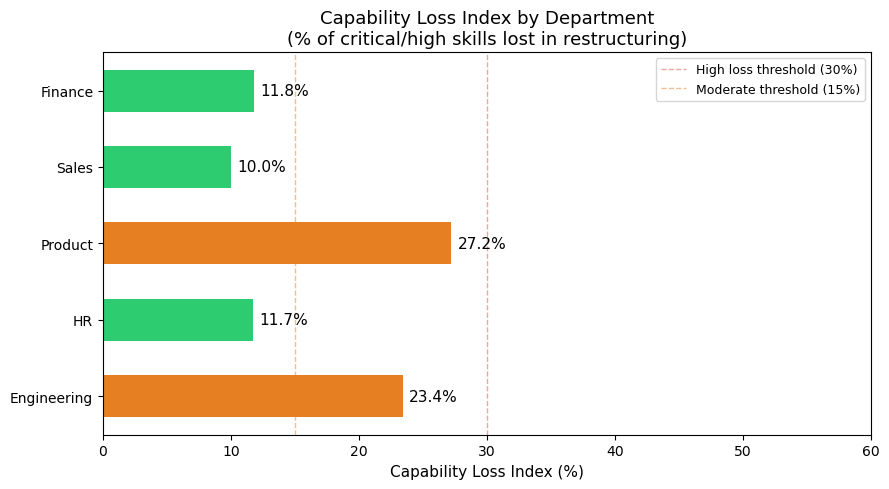

Chart saved.


In [31]:
fig, ax = plt.subplots(figsize=(9, 5))

depts = list(cli_scores.keys())
scores = list(cli_scores.values())
colors = ['#e74c3c' if s >= 30 else '#e67e22' if s >= 15 else '#2ecc71' for s in scores]

bars = ax.barh(depts, scores, color=colors, height=0.55)
ax.set_xlim(0, 60)
ax.axvline(30, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1, label='High loss threshold (30%)')
ax.axvline(15, color='#e67e22', linestyle='--', alpha=0.5, linewidth=1, label='Moderate threshold (15%)')

for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{score}%', va='center', fontsize=11)

ax.set_xlabel('Capability Loss Index (%)', fontsize=11)
ax.set_title('Capability Loss Index by Department\n(% of critical/high skills lost in restructuring)', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(r"C:\Users\annwe\Desktop\project 4\outputs\charts\capability_loss_index.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

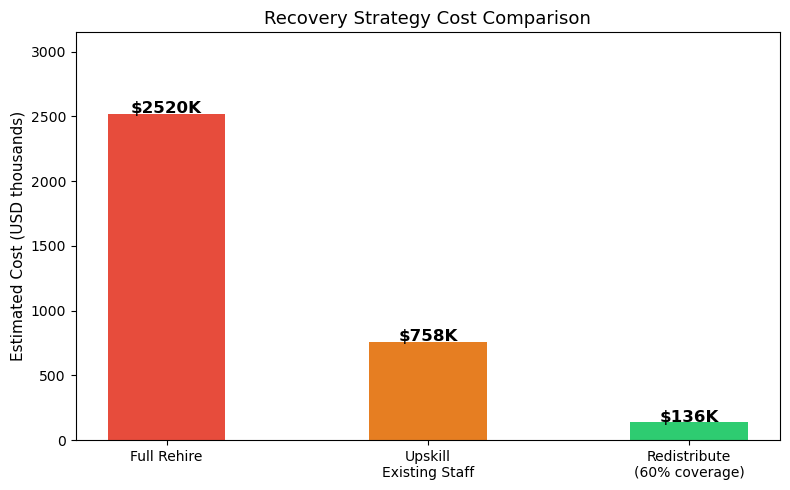

Chart saved.


In [33]:
strategies = ['Full Rehire', 'Upskill\nExisting Staff', 'Redistribute\n(60% coverage)']
costs = [rehire_cost, upskill_total, redistribute_cost]
bar_colors = ['#e74c3c', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(strategies, [c/1000 for c in costs], color=bar_colors, width=0.45)

for bar, cost in zip(bars, costs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'${cost/1000:.0f}K', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Estimated Cost (USD thousands)', fontsize=11)
ax.set_title('Recovery Strategy Cost Comparison', fontsize=13)
ax.set_ylim(0, max([c/1000 for c in costs]) * 1.25)
plt.tight_layout()
plt.savefig(r"C:\Users\annwe\Desktop\project 4\outputs\charts\recovery_cost_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

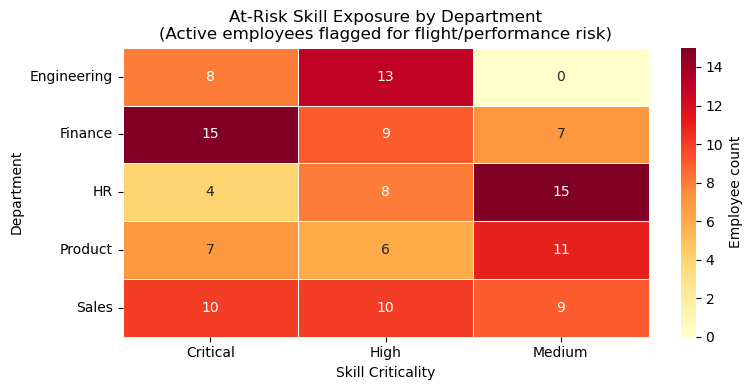

Chart saved.


In [35]:
risk_pivot = at_risk_skills.groupby(['department', 'criticality']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(risk_pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Employee count'})
ax.set_title('At-Risk Skill Exposure by Department\n(Active employees flagged for flight/performance risk)', fontsize=12)
ax.set_xlabel('Skill Criticality')
ax.set_ylabel('Department')
plt.tight_layout()
plt.savefig(r"C:\Users\annwe\Desktop\project 4\outputs\charts\atrisk_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [39]:
summary_data = {
    'Department': list(cli_scores.keys()),
    'Capability_Loss_Index_Pct': list(cli_scores.values()),
    'Loss_Rating': ['High' if v >= 30 else 'Moderate' if v >= 15 else 'Low' for v in cli_scores.values()]
}

recovery_data = {
    'Strategy': ['Full Rehire', 'Upskill Existing Staff', 'Redistribute (60% coverage)'],
    'Estimated_Cost_USD': [rehire_cost, upskill_total, redistribute_cost],
    'Coverage_Pct': [100, 100, 60],
    'Recommended': ['No', 'Conditional', 'Yes — start here']
}

at_risk_summary = at_risk_df.groupby('department').agg(
    at_risk_headcount=('employee_id', 'count'),
    avg_performance=('performance_score', 'mean'),
    avg_tenure=('tenure_years', 'mean')
).reset_index().round(2)

with pd.ExcelWriter(
    r"C:\Users\annwe\Desktop\project 4\outputs\talent_simulator_output.xlsx",
    engine='openpyxl'
) as writer:
    pd.DataFrame(summary_data).to_excel(writer, sheet_name='Capability Loss Index', index=False)
    pd.DataFrame(recovery_data).to_excel(writer, sheet_name='Recovery Cost Comparison', index=False)
    at_risk_summary.to_excel(writer, sheet_name='At-Risk Summary', index=False)
    df.to_excel(writer, sheet_name='Raw Data', index=False)
    lost_critical_skills.reset_index().rename(columns={'index': 'skill', 'skill': 'instances_lost'}).to_excel(
        writer, sheet_name='Skills Lost', index=False
    )

print("Excel file saved with 5 sheets.")

Excel file saved with 5 sheets.
